In [21]:
import os
import time
import umap
import yaml
import torch
import random
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as datetime 
import matplotlib.pyplot as plt 
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset, default_collate
from mm_cgmvae import *
from train_mmvae import*
from VAE_model_architectures import*

In [22]:
params = {
    'general': {
'dataset': 'AD',  # DO
'model_type': 'CGMVAE', # VAE or CVAE or GMVAE 
'random_seed': 10, # 85 # 123 for same region, seed 22 for multi-region no offset, 22 for multi-region offset
'learn_prior': False,
'accelerator': True,
'M': 2,
'epochs': 100,
'num_iwae_samples': 1, 
'learning_rate': 1e-3, 
'offset_centers': False
    }
}

dataset = params['general']['dataset']
model_type = params['general']['model_type']
random_seed = params['general']['random_seed']
learn_prior = params['general']['learn_prior']
accelerator = params['general']['accelerator']
M = params['general']['M']
epochs = params['general']['epochs']
num_iwae_samples = params['general']['num_iwae_samples']
learning_rate = params['general']['learning_rate']
offset_centers = params['general']['offset_centers']

In [23]:
if dataset == 'AD':
    dataset_params = {
    'input_dim': [4842, 4850], # CHANGE BACK to 4841, 4841
    'H1': [128, 128], 
    'H2': [64, 64], 
    'H3': [32, 32],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['HC', 'PFC'], # CHANGE BACK 'HC1', 'HC2'
    'output_folder': '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_testnotrainosd_seed15',
    #'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sameregionhc_paired.csv',
    'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100,
    'train_osd': False
    }
elif dataset == 'DO':
    dataset_params = {
    'input_dim': [5873, 36],
    'H1': [128, 35], 
    'H2': [64, 16], 
    'H3': [32, 10],
    'latent_dim': 10,
    'batch_size': 271, # divided by length, 9751 / 971 leaves last batch = 271
    'scales': [1, 1],
    'dataset_abbrev': ['Geno', 'Physio'],
    'output_folder': '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/vanillavae4_genoreweighted_test',
    'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv',
    #'input_path': '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio.csv',
    'gmm_centers_path': '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv',
    'gmm_std': 2,
    'num_classes': 4,
    'num_kl_samples': 100,
    'train_osd': False
    }
params['dataset_params'] = dataset_params
input_dim = params['dataset_params']['input_dim']
H1 = params['dataset_params']['H1']
H2 = params['dataset_params']['H2']
H3 = params['dataset_params']['H3']
latent_dim = params['dataset_params']['latent_dim']
batch_size = params['dataset_params']['batch_size']
scales = params['dataset_params']['scales']
dataset_abbrev = params['dataset_params']['dataset_abbrev']
output_folder = params['dataset_params']['output_folder']
input_path = params['dataset_params']['input_path']
gmm_centers_path = params['dataset_params']['gmm_centers_path']
gmm_std = params['dataset_params']['gmm_std']
num_classes = params['dataset_params']['num_classes']
num_kl_samples = params['dataset_params']['num_kl_samples']
train_osd = params['dataset_params']['train_osd']

In [24]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# save params in a yaml file 
with open(f"{output_folder}/config.yaml", "w") as f:
    yaml.dump(params, f)

In [25]:
# set seed
# np.random.seed(random_seed)
# torch.manual_seed(random_seed)
# torch.cuda.manual_seed_all(random_seed)
# # set seed
# os.environ["PYTHONHASHSEED"] = str(random_seed)
# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

# def set_seed(seed: int = random_seed):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     torch.use_deterministic_algorithms(True)
# set_seed(random_seed)

In [26]:
def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
set_seed(random_seed)

In [27]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    return (input_array - mean)/std

def numpyToTensor(x):
    return torch.from_numpy(x)

In [28]:
class PairedDataset(Dataset):
    def __init__(self, paired_df, input_dims, label_col, cfm_col, dataset, residual_col, strain_col):
        self.paired_df = paired_df
        self.dataset = dataset
        if dataset == 'AD':
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2, self.residuals, self.strain = load_pairedregion_data(paired_df, input_dims[0], input_dims[1], label_col, cfm_col, residual_col, strain_col)
            self.residuals = numpyToTensor(self.residuals)
            self.strain = self.strain
        elif dataset == 'DO': 
            self.df1_layer1, self.x1, self.label1, self.cfm1, self.df2_layer1, self.x2, self.label2, self.cfm2 = load_pairedmodal_data(paired_df, input_dims[0], label_col, cfm_col)
        self.df1_layer1 = numpyToTensor(self.df1_layer1)
        self.x1 = numpyToTensor(self.x1)
        self.cfm1 = numpyToTensor(self.cfm1)
        self.label1 = numpyToTensor(self.label1)

        self.df2_layer1 = numpyToTensor(self.df2_layer1)
        self.x2 = numpyToTensor(self.x2)
        self.cfm2 = numpyToTensor(self.cfm2)
        self.label2 = numpyToTensor(self.label2)

    def __len__(self):
        return len(self.paired_df)
    def __getitem__(self, index):
        if self.dataset == 'AD':
            return (self.df1_layer1[index], self.x1[index], self.label1[index], self.cfm1[index]), (self.df2_layer1[index], self.x2[index], self.label2[index], self.cfm2[index]), (self.residuals[index]), (self.strain[index])
    
        else:
            return (self.df1_layer1[index], self.x1[index], self.label1[index], self.cfm1[index]), (self.df2_layer1[index], self.x2[index], self.label2[index], self.cfm2[index])
    
def load_pairedregion_data(df, input_dim1, input_dim2, label_col, cfm_col, residual_col, strain_col):
    x1 = df[list(df.columns[0:input_dim1])].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df[list(df.columns[0:input_dim1])].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df[list(df.columns[4852:4852+input_dim2])].values.astype('float32') # CHANGE back to df.columns[4851:4851+input_dim2]
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df[list(df.columns[4852:4852+input_dim2])].copy() # CHANGE BACK to df.columns[4851:4851+input_dim2]
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    residuals = df[residual_col].values
    strain = df[strain_col].values

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2, residuals, strain

def load_pairedmodal_data(df, input_dim1, label_col, cfm_col):
    x1 = df.iloc[:, 1:input_dim1+1].values.astype('float32')
    label1 = df[label_col].values
    cfm1 = df[cfm_col].values
    df1_layer1 = df.iloc[:, 1:input_dim1+1].copy()
    df1_layer1['cfm'] = cfm1
    df1_layer1 = df1_layer1.values.astype('float32')

    x2 = df.iloc[:, input_dim[0]+1:-5].values.astype('float32')
    label2 = df[label_col].values
    cfm2 = df[cfm_col].values
    df2_layer1 = df.iloc[:, input_dim[0]+1:-5].copy()
    df2_layer1['cfm'] = cfm2
    df2_layer1 = df2_layer1.values.astype('float32')

    return df1_layer1, x1, label1, cfm1, df2_layer1, x2, label2, cfm2

In [29]:
# will need to make dataloaders for DO dataset after I decide how to structure the model input

In [30]:
paired_df = pd.read_csv(input_path, low_memory=False)
if dataset == 'AD':
    label_col = '14-6-Bin_HC' # CHANGE BACK
    cfm_col = 'CFM_14_5_snRNA_HC' # CHANGE BACK
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    #paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
            'strain': paired_df['strain'],
            '14-6-residual': paired_df['14-6-residual_HC'] # CHANGE BACK
        }
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset, '14-6-residual_HC', 'strain')
    test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset, '14-6-residual_HC', 'strain')
elif dataset == 'DO':
    label_col = 'cfc_bin'
    cfm_col = 'CFC.24mo.Average'
    paired_df[cfm_col] = standardizer(paired_df[cfm_col])
    meta = {
        'mouse_id': paired_df['Mouse.ID'], 
        'diet': paired_df['Diet']
    } 
    paired_df_train = paired_df.sample(frac=1, random_state=random_seed)
    train_dataset = PairedDataset(paired_df_train, input_dim, label_col, cfm_col, dataset)
    test_dataset = PairedDataset(paired_df, input_dim, label_col, cfm_col, dataset)

In [31]:
# train_loader = DataLoader(train_dataset, batch_size=batch_size)
# test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [32]:
def _seed_worker(worker_id):
    worker_seed = random_seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_seed)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, worker_init_fn=_seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), num_workers=0, worker_init_fn=_seed_worker, generator=g)

In [33]:
first_iter = next(iter(train_loader))

In [34]:
type(first_iter[3][0])

str

In [35]:
if offset_centers: 
    gmm_centers = []
    ks_weights = []
    cv_weights = []
    all_samples = []
    if model_type == 'CGMVAE':
        for dataset in dataset_abbrev:
            gmm_path = f"/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/{dataset}_priors.csv"
            gmm = pd.read_csv(gmm_path)
            gmm = gmm.iloc[:, 1:].T
            ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm.values]).float().squeeze(), gmm_std, num_kl_samples)
            samples_df = pd.DataFrame(samples)
            samples_df['components'] = components 
            all_samples.append(samples_df)
            samples_df.to_csv(os.path.join(output_folder, f'gmm_samples_{dataset}encoder.csv'), index=False)
            gmm_centers.append(torch.tensor([gmm.values]).float().squeeze())
            ks_weights.append(ks_weight)
            cv_weights.append(cv_weight)
else: 
    gmm_centers = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers_4gaussian_14mon_fromQRT.csv')
    gmm_centers = gmm_centers.iloc[:, 1:].T
    gmm_std = 2
    ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)
    ks_weights = [ks_weight, ks_weight]
    cv_weights = [cv_weight, cv_weight]
    gmm_centers = [torch.tensor([gmm_centers.values]).float().squeeze(), torch.tensor([gmm_centers.values]).float().squeeze()]

In [36]:
# if model_type == 'CGMVAE':
#     gmm_centers = pd.read_csv(gmm_centers_path)
#     gmm_centers = gmm_centers.iloc[:, 1:].T
#     ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)
#     model = MM_CGMVAE(input_dim, H1, H2, H3, latent_dim, scales, num_classes, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, ks_weight, cv_weight)
# model.to(device)
# optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [37]:
model = MM_CGMVAE(input_dim, H1, H2, H3, latent_dim, scales, num_classes, gmm_centers, gmm_std, ks_weights, cv_weights)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, amsgrad=False)

In [38]:
# initialize loss vectors
# total_loss = []
# osd_epochs = []
# total_test_loss = []
# test_epochs = []
# individual_loss = {}
# recon_loss = {}
# mse_losses = {}
# mse_cfm_losses = {}
# for i, set in enumerate(dataset_abbrev): 
#     individual_loss[set] = {}
#     individual_loss[set]['lpx_z'] = []
#     individual_loss[set]['kls'] = []
#     recon_loss[set] = {}
#     mse_losses[set] = {}
#     mse_cfm_losses[set] =  {}
#     if i ==  0:
#         recon_loss[set][set] = []
#         recon_loss[set][dataset_abbrev[i+1]] = []
#         mse_losses[set][set] = []
#         mse_losses[set][dataset_abbrev[i+1]] = []
#         mse_cfm_losses[set][set] = []
#         mse_cfm_losses[set][dataset_abbrev[i+1]] = []
#     else:
#         recon_loss[set][set] = []
#         recon_loss[set][dataset_abbrev[i-1]] = []
#         mse_losses[set][set] = []
#         mse_losses[set][dataset_abbrev[i-1]] = []
#         mse_cfm_losses[set][set] = []
#         mse_cfm_losses[set][dataset_abbrev[i-1]] = []

In [39]:
# initialize loss vectors
total_loss = []
osd_epochs = []
total_test_loss = []
test_epochs = []
bin_means_epochs = []
individual_loss = {}
recon_loss = {}
mse_losses = {}
mse_cfm_losses = {}
for i, set in enumerate(dataset_abbrev): 
    individual_loss[f'{set}_lpx_z'] = []
    individual_loss[f'{set}_kls'] = []
    # recon_loss[set] = {}
    # mse_losses[set] = {}
    # mse_cfm_losses[set] =  {}
    if i ==  0:
        recon_loss[f'{set}_{set}'] = []
        recon_loss[f'{set}_{dataset_abbrev[i+1]}'] = []
        mse_losses[f'{set}_{set}'] = []
        mse_losses[f'{set}_{dataset_abbrev[i+1]}'] = []
        mse_cfm_losses[f'{set}_{set}'] = []
        mse_cfm_losses[f'{set}_{dataset_abbrev[i+1]}'] = []
    else:
        recon_loss[f'{set}_{set}'] = []
        recon_loss[f'{set}_{dataset_abbrev[i-1]}'] = []
        mse_losses[f'{set}_{set}'] = []
        mse_losses[f'{set}_{dataset_abbrev[i-1]}'] = []
        mse_cfm_losses[f'{set}_{set}'] = []
        mse_cfm_losses[f'{set}_{dataset_abbrev[i-1]}'] = []

In [40]:
start_time = time.time()
for epoch in range(1, epochs+1):
    loss, lpx_zs, kls, lpxz_ind, mse_loss, mse_cfm_loss, osd, bin_means = train(epoch, model, optimizer, train_loader, num_iwae_samples, device, epochs, model_type, train_osd)
    print('one iteration done')
    osd_epochs.append(osd)
    total_loss.append(loss)
    bin_means_epochs.append(bin_means)
    for i, set in enumerate(dataset_abbrev): 
        individual_loss[f'{set}_lpx_z'].append(lpx_zs[i]) 
        individual_loss[f'{set}_kls'].append(kls[i])
        if i ==  0:
            recon_loss[f'{set}_{set}'].append(lpxz_ind[0] / len(train_loader))
            recon_loss[f'{set}_{dataset_abbrev[i+1]}'].append(lpxz_ind[1] / len(train_loader))
            mse_losses[f'{set}_{set}'].append(mse_loss[0])
            mse_losses[f'{set}_{dataset_abbrev[i+1]}'].append(mse_loss[1])
            mse_cfm_losses[f'{set}_{set}'].append(mse_cfm_loss[0])
            mse_cfm_losses[f'{set}_{dataset_abbrev[i+1]}'].append(mse_cfm_loss[1])
        else:
            recon_loss[f'{set}_{set}'].append(lpxz_ind[3] / len(train_loader))
            recon_loss[f'{set}_{dataset_abbrev[i-1]}'].append(lpxz_ind[2] / len(train_loader))
            mse_losses[f'{set}_{set}'].append(mse_loss[3])
            mse_losses[f'{set}_{dataset_abbrev[i-1]}'].append(mse_loss[2])
            mse_cfm_losses[f'{set}_{set}'].append(mse_cfm_loss[3])
            mse_cfm_losses[f'{set}_{dataset_abbrev[i-1]}'].append(mse_cfm_loss[2])
    if epoch in [epochs / 2, epochs]:
        test_epochs.append(epoch)
        test(epoch, model, optimizer, test_loader, num_iwae_samples, device, output_folder, dataset_abbrev, meta)
end_time = time.time()
print(str(end_time - start_time) + ' seconds for training/testing')

====> Epoch: 001 Train loss: 26835.1073
one iteration done
====> Epoch: 002 Train loss: 26207.3818
one iteration done
====> Epoch: 003 Train loss: 24891.3688
one iteration done
====> Epoch: 004 Train loss: 22243.2323
one iteration done
====> Epoch: 005 Train loss: 19228.2696
one iteration done
====> Epoch: 006 Train loss: 16995.0296
one iteration done
====> Epoch: 007 Train loss: 14656.8324
one iteration done
====> Epoch: 008 Train loss: 12358.3125
one iteration done
====> Epoch: 009 Train loss: 9569.6119
one iteration done
====> Epoch: 010 Train loss: 7196.2175
one iteration done
====> Epoch: 011 Train loss: 5503.3348
one iteration done
====> Epoch: 012 Train loss: 4356.3408
one iteration done
====> Epoch: 013 Train loss: 3532.9840
one iteration done
====> Epoch: 014 Train loss: 3088.6640
one iteration done
====> Epoch: 015 Train loss: 2778.6964
one iteration done
====> Epoch: 016 Train loss: 2566.5544
one iteration done
====> Epoch: 017 Train loss: 2354.3584
one iteration done
====> 

In [41]:
# Save loss vectors 
pd.DataFrame(individual_loss).to_csv(os.path.join(output_folder, 'individual_loss.csv'), index=False)
pd.DataFrame(recon_loss).to_csv(os.path.join(output_folder, 'recon_loss.csv'), index=False)
pd.DataFrame(mse_losses).to_csv(os.path.join(output_folder, 'mse_losses.csv'), index=False)
pd.DataFrame(mse_cfm_losses).to_csv(os.path.join(output_folder, 'mse_cfm_losses.csv'), index=False)
pd.DataFrame(osd_epochs).to_csv(os.path.join(output_folder, 'osd_over_epochs.csv'), index=False)
pd.DataFrame(bin_means_epochs).to_csv(os.path.join(output_folder, 'bin_means_epochs.csv'), index=False)

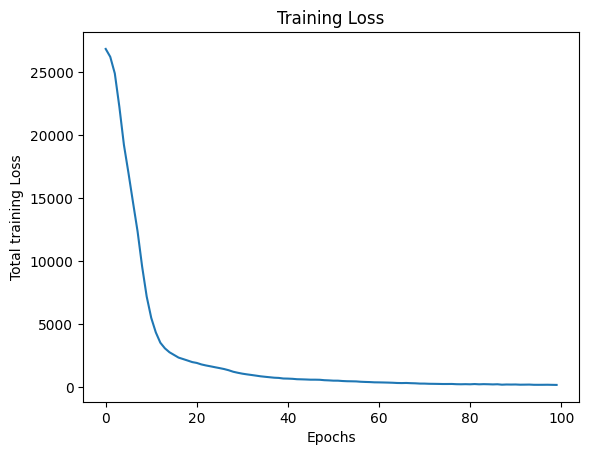

In [42]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

In [43]:
if train_osd: 
    plt.figure()
    plt.plot(osd_epochs, label='OSD')                                                                          
    plt.title('OSD over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('OSD')            
    plt.savefig(os.path.join(output_folder, 'osd_over_epochs.png'))

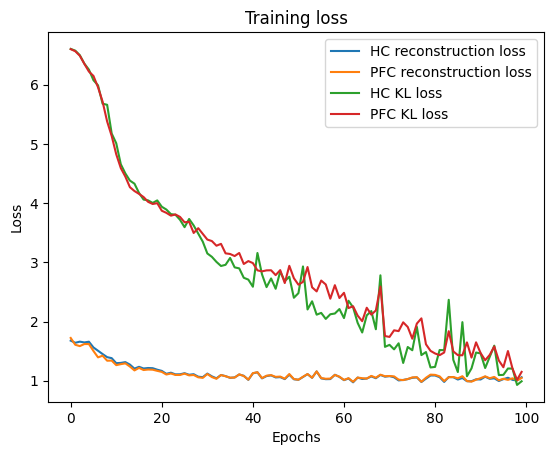

In [44]:
plt.figure()
names = ['reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        plt.plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]} {names[i]}')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(output_folder, 'recon_kl_oneplot.png'))

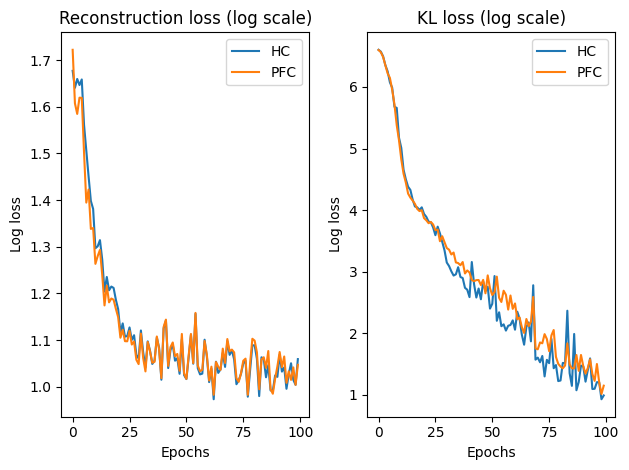

In [45]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(np.log(individual_loss[f'{dataset_abbrev[j]}_{set}']), label=f'{dataset_abbrev[j]}')
    ax[i].set_title(f'{names[i]} (log scale)')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

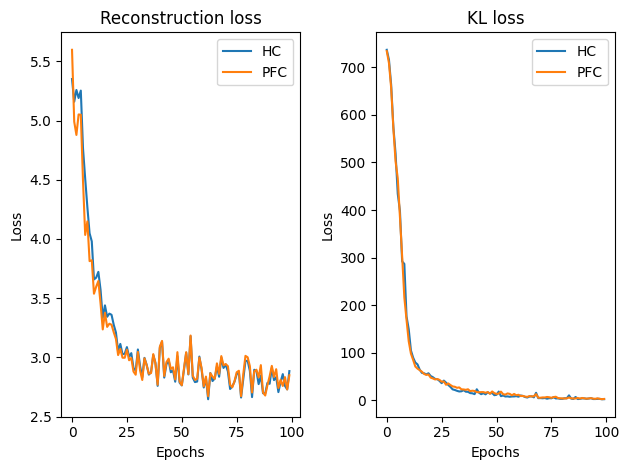

In [46]:
fig, ax = plt.subplots(1, 2)
names = ['Reconstruction loss', 'KL loss']
for i, set in enumerate(['lpx_z', 'kls']):
    for j, abbrev in enumerate(dataset_abbrev):
        ax[i].plot(individual_loss[f'{dataset_abbrev[j]}_{set}'], label=f'{dataset_abbrev[j]}')
    ax[i].set_title(names[i])
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Loss')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

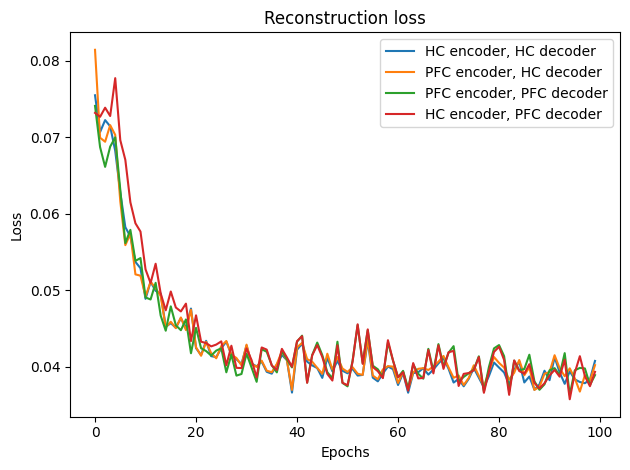

In [47]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot((recon_loss[f'{set}_{set}']), label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((recon_loss[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((recon_loss[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Reconstruction loss')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

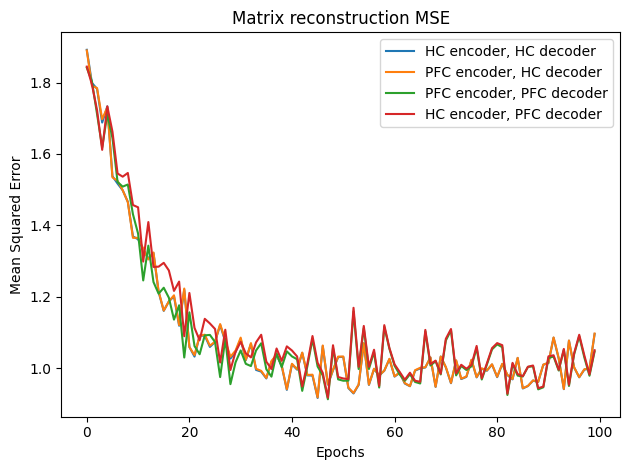

In [48]:
# Plotting each kind of reconstruction
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_graphs.png'))

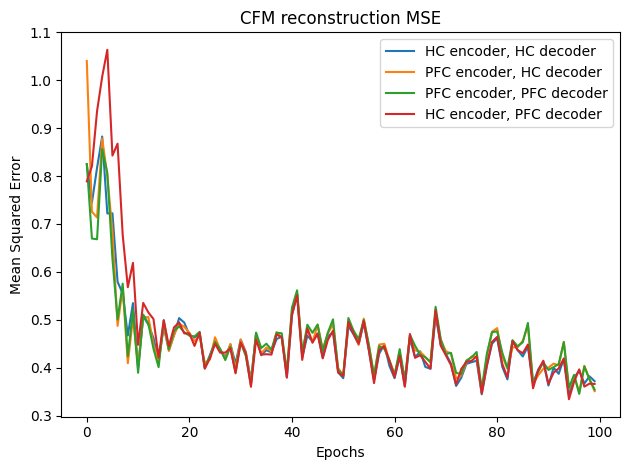

In [49]:
# Plotting each kind of reconstruction (cfm mse)
for i, set in enumerate(dataset_abbrev):
    plt.plot(mse_cfm_losses[f'{set}_{set}'], label=f'{set} encoder, {set} decoder')
    if i == 0:
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i+1]}_{set}']), label=f'{dataset_abbrev[i+1]} encoder, {set} decoder')
    else: 
        plt.plot((mse_cfm_losses[f'{dataset_abbrev[i-1]}_{set}']), label=f'{dataset_abbrev[i-1]} encoder, {set} decoder')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_mse_cfm_graphs.png'))

Visualizing the latent space

In [50]:
hues=['encoder', 'bin']

In [51]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [52]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [53]:
latent_space_1

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual
0,-10.259019,-5.810900,3.852050,7.470180,12.409733,20.181830,28.663633,31.969202,38.632970,38.281326,3,1.243151,HC,124,1.277393
1,-7.737457,-5.555582,1.691031,7.390794,14.159375,18.815770,26.780577,32.359673,40.761887,38.767372,3,1.243151,HC,124,1.277393
2,-10.685719,-3.187401,4.194278,9.744405,14.442339,19.849815,26.515705,31.388943,37.806786,38.675793,3,1.243151,HC,124,1.277393
3,-7.667303,-7.045063,2.220304,12.899897,10.072422,19.003944,28.614407,31.095287,36.640040,40.523792,3,1.243151,HC,124,1.277393
4,-9.091844,-4.905219,2.531580,6.628301,11.100729,17.822110,24.641665,28.390360,36.882590,36.474500,3,1.243151,HC,124,1.277393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,-28.596870,-21.778965,-20.481636,-13.833172,-4.901486,-6.188919,0.450629,1.181066,7.139831,12.524150,1,-0.215123,HC,28,-0.576731
9747,-22.473324,-18.135616,-17.877470,-13.033784,-9.321046,-5.902563,-3.706957,3.799990,6.859186,11.252659,1,-0.215123,HC,28,-0.576731
9748,-25.953210,-19.407627,-19.322510,-15.388294,-5.023006,-3.453290,-0.700984,3.366882,7.987315,12.755141,1,-0.215123,HC,28,-0.576731
9749,-16.603846,-15.092307,-13.619501,-12.092870,-4.156800,-4.861716,-0.955634,1.226809,7.395506,7.999999,1,-0.215123,HC,28,-0.576731


In [54]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

In [55]:
prior_samples = pd.DataFrame(samples)
prior_samples['components'] = components

<Axes: xlabel='LV1', ylabel='Density'>

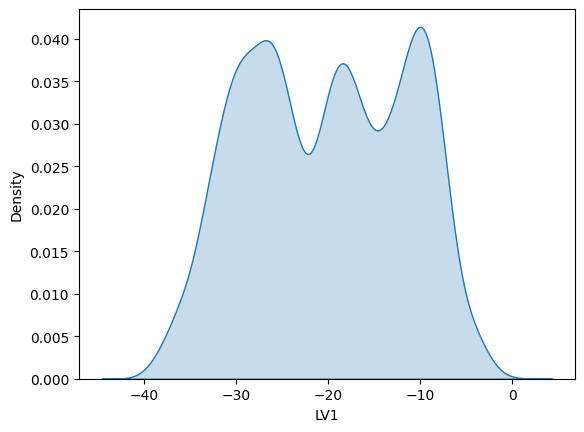

In [56]:
sns.kdeplot(data=latent_space_comb['LV1'], fill=True)

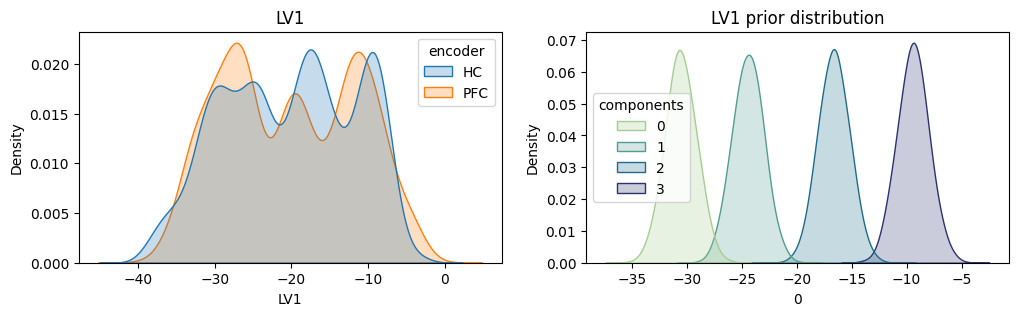

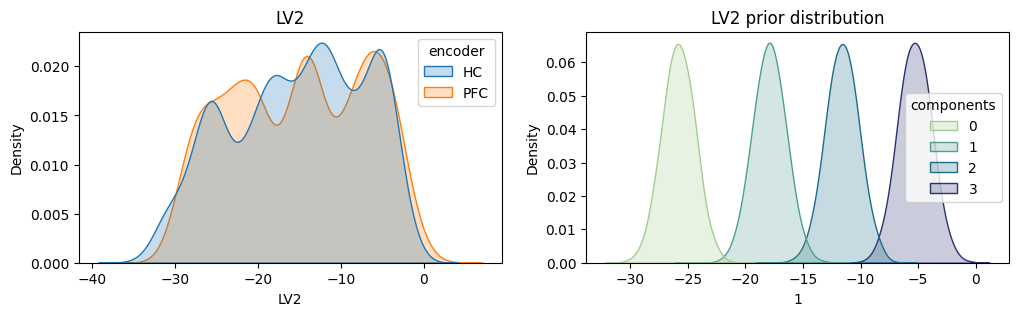

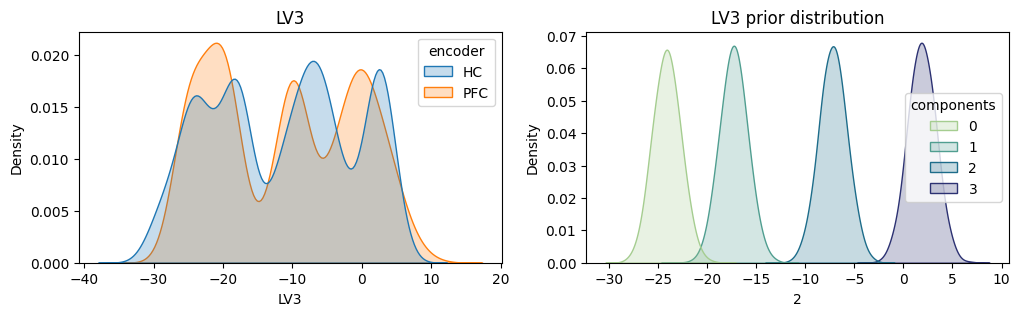

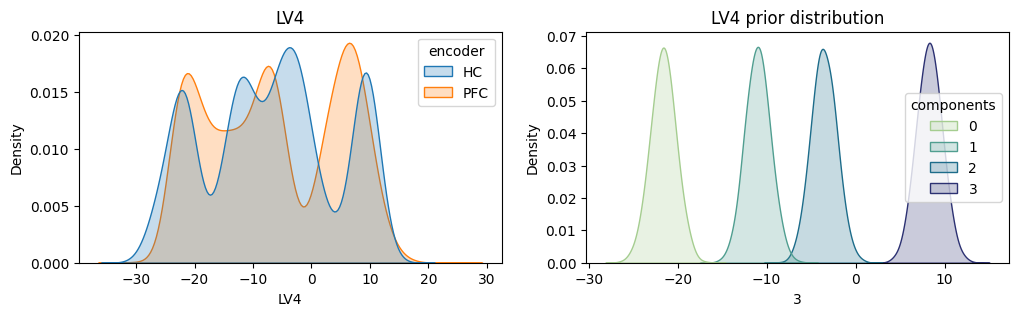

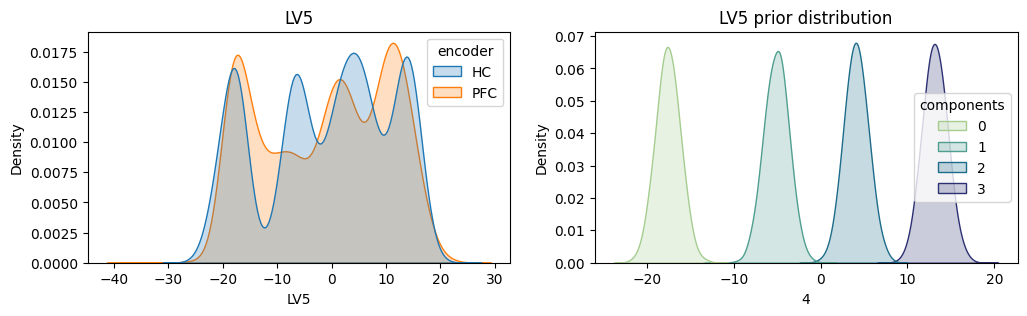

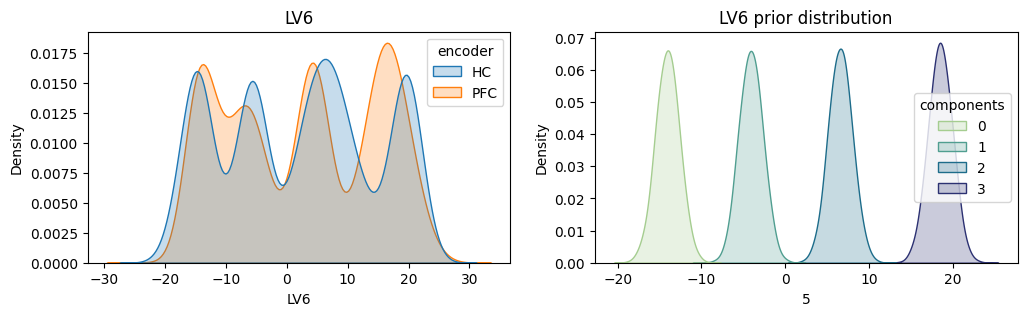

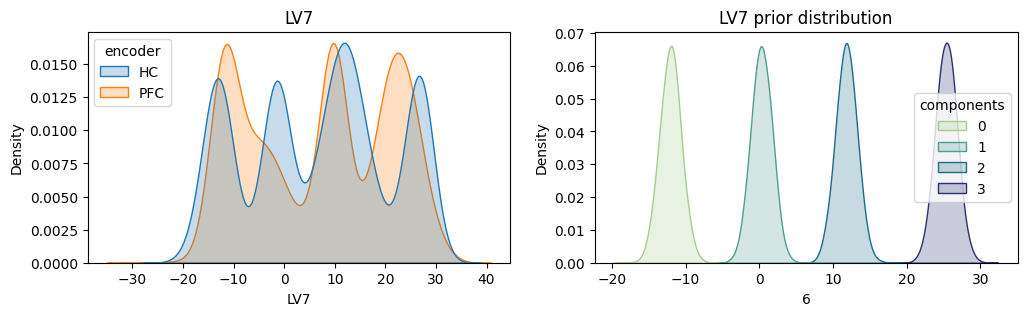

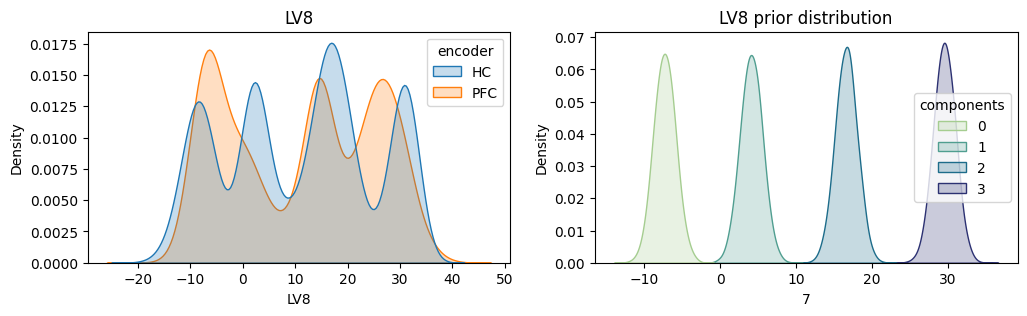

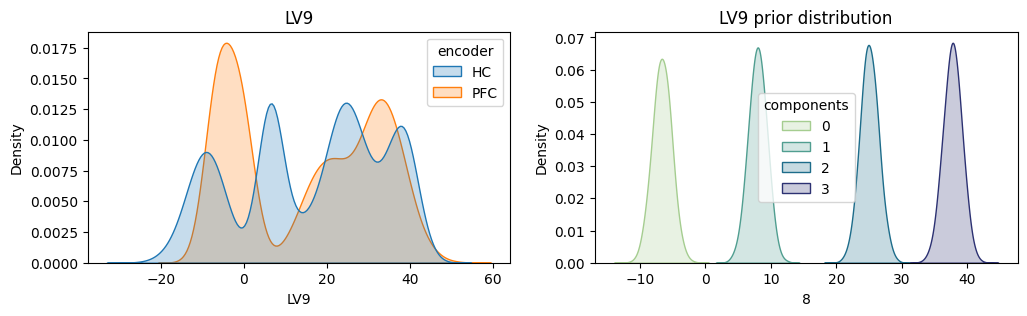

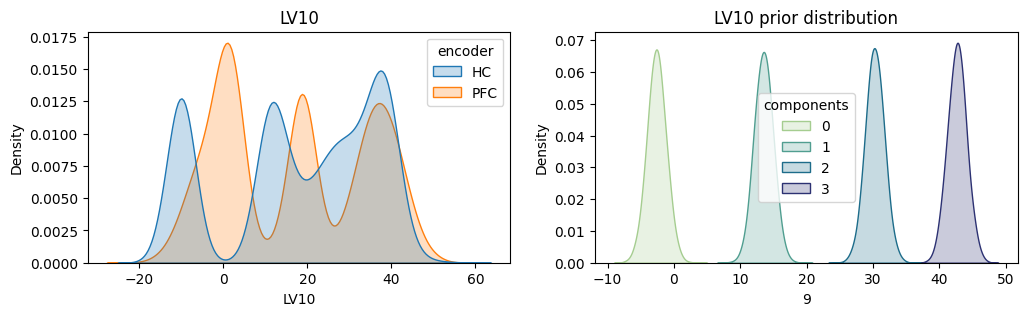

In [57]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=1, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

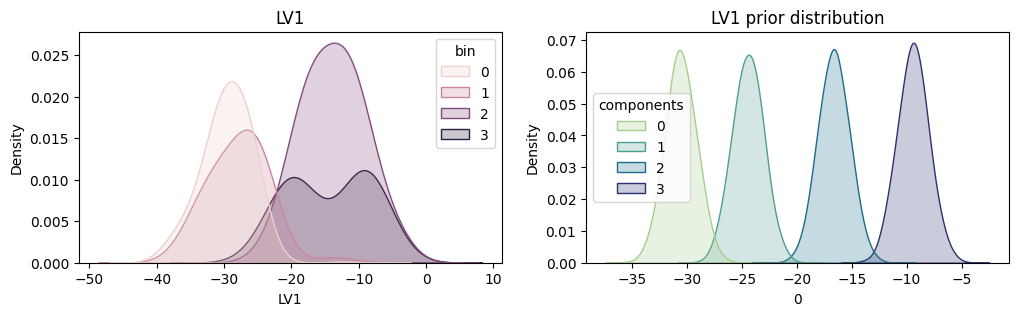

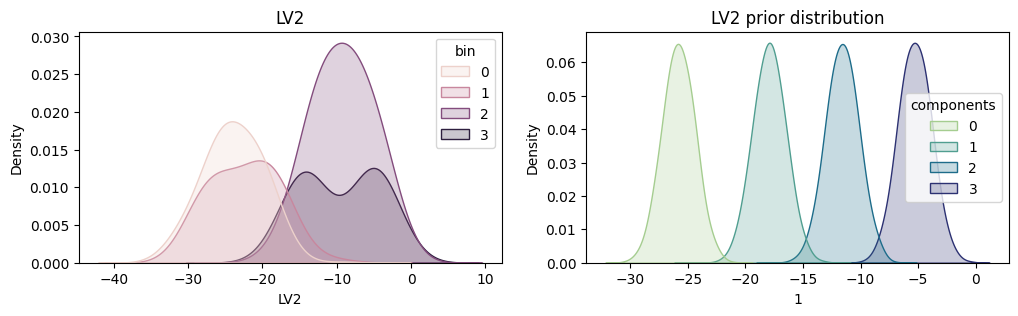

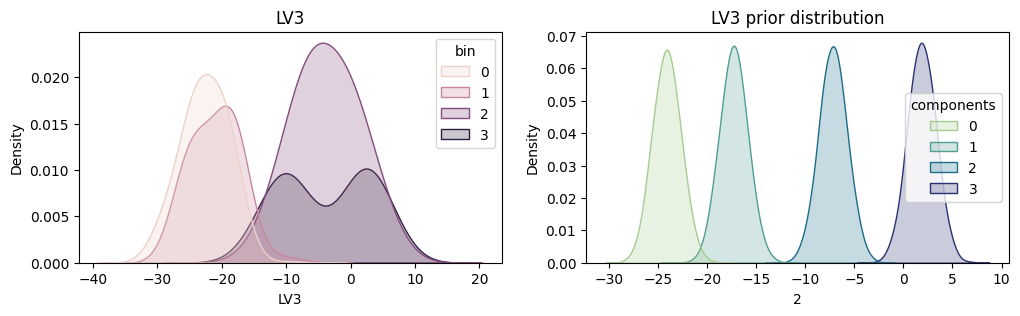

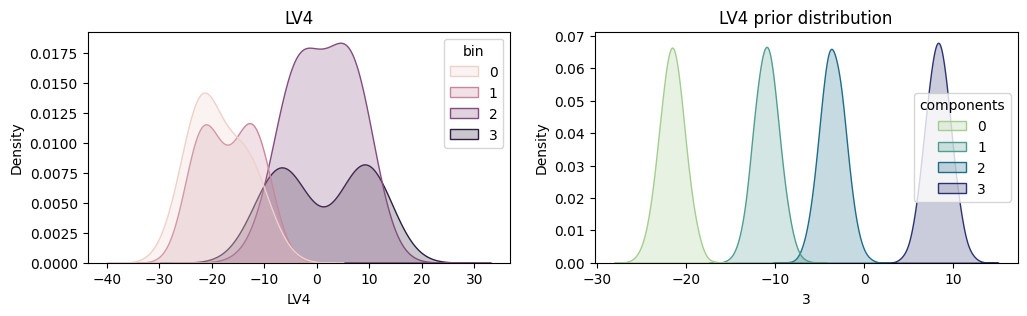

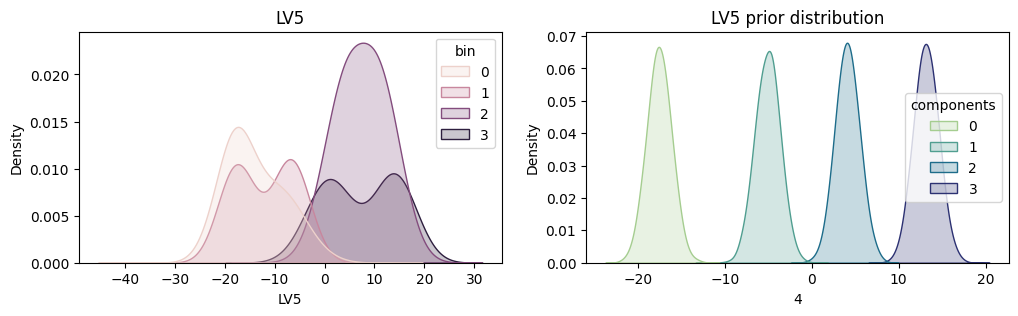

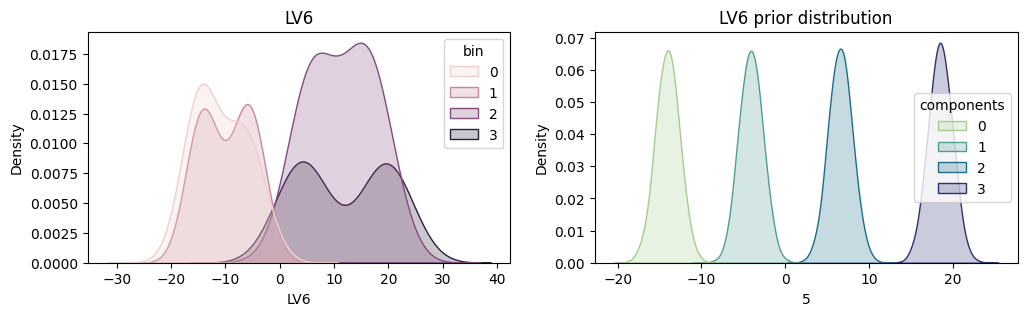

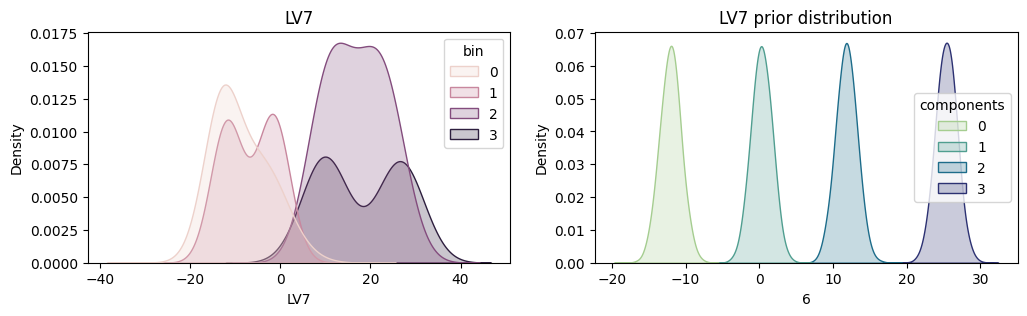

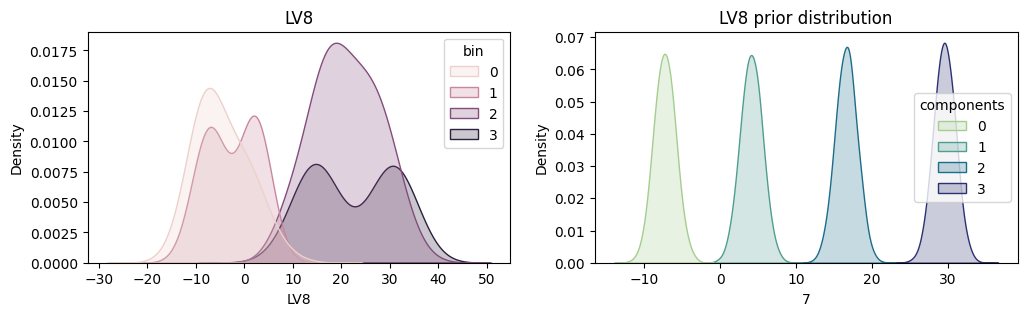

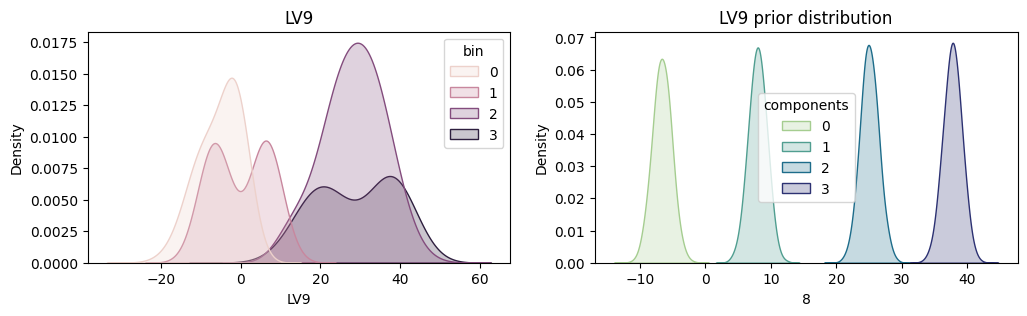

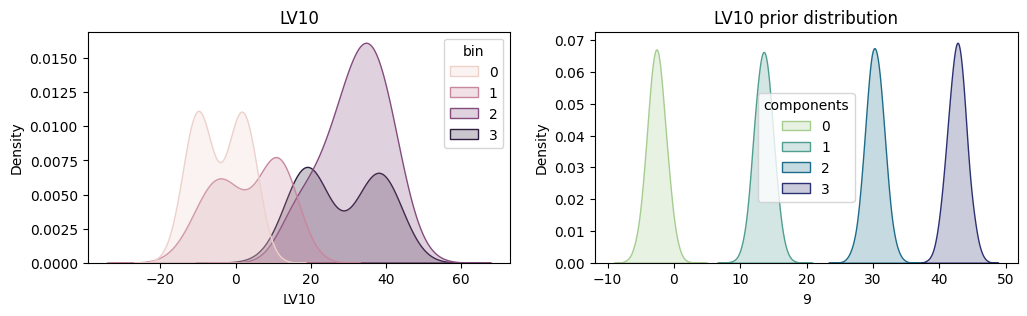

In [58]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    sns.kdeplot(data=latent_space_comb[[column, 'bin']], x=column, hue='bin', fill=True, bw_adjust=3, ax=ax[0])
    ax[0].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(f'{column} prior distribution')

In [59]:
latent_space_comb['bin_enc'] = latent_space_comb['bin'].astype(str) + '_' +  latent_space_comb['encoder']

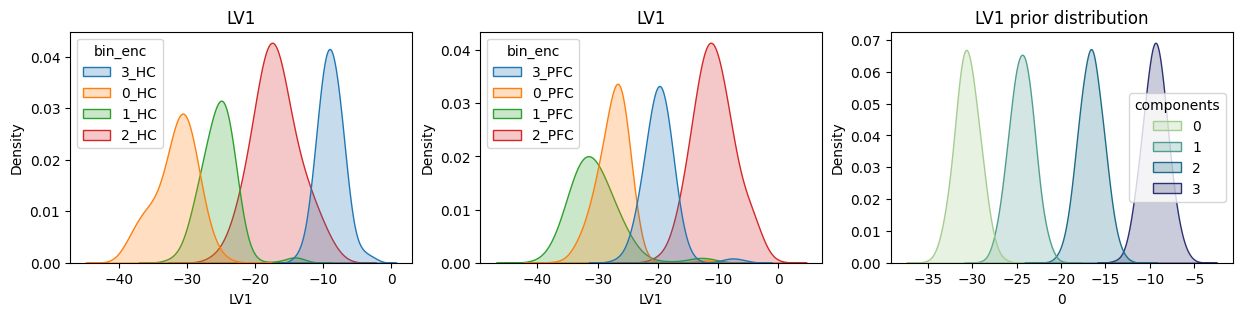

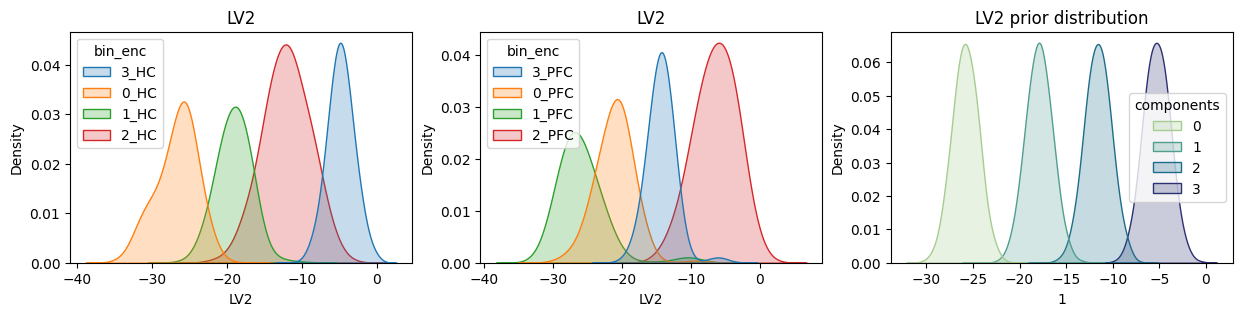

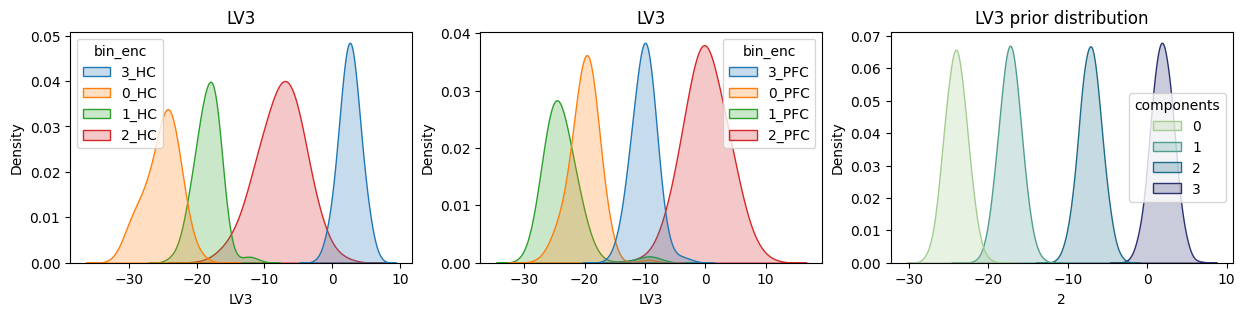

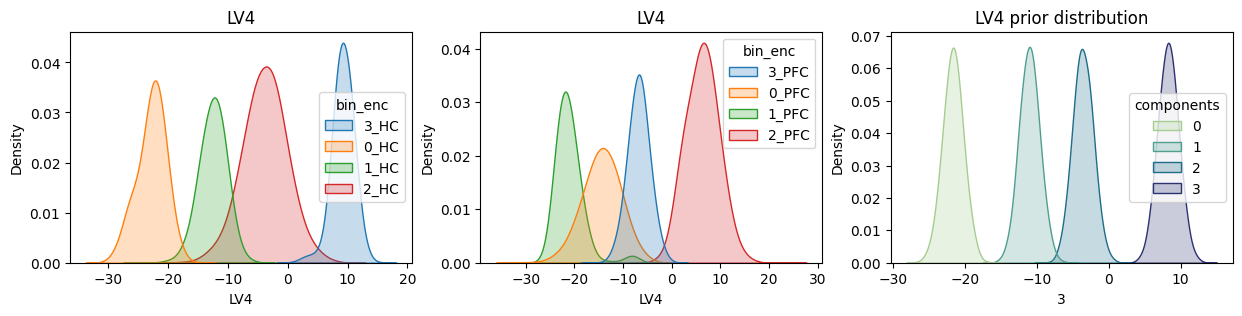

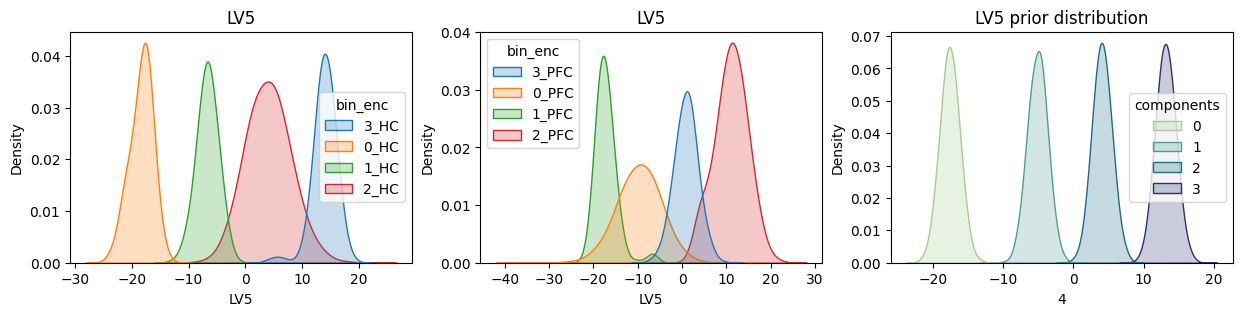

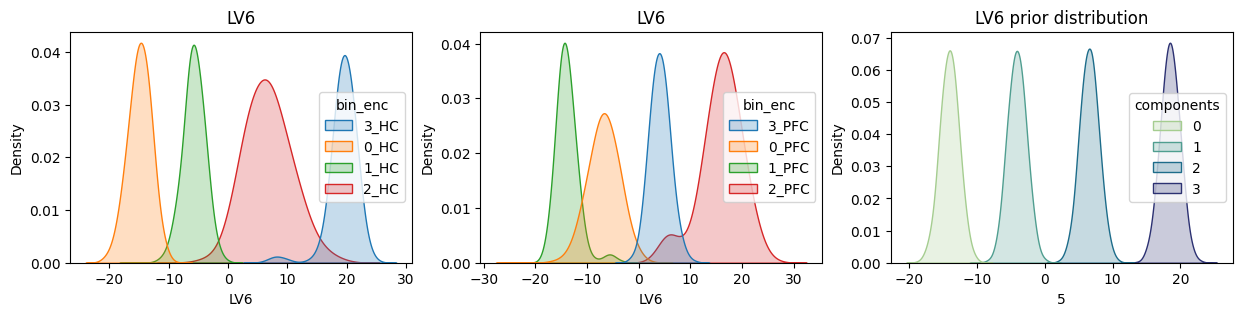

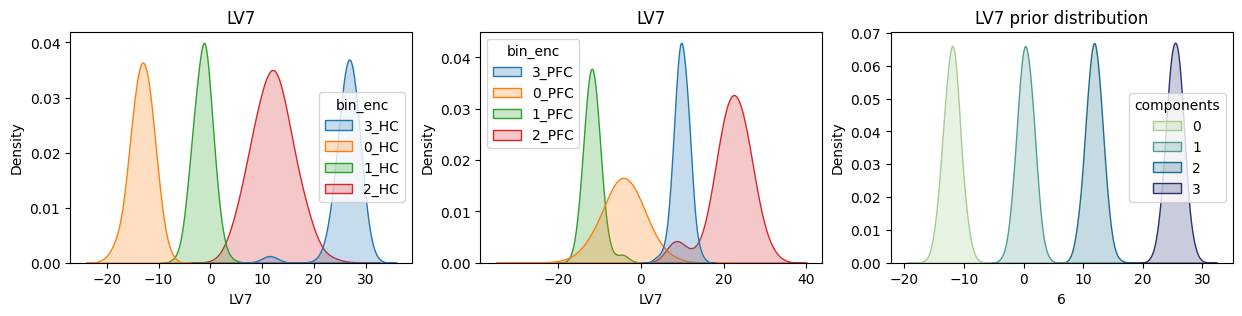

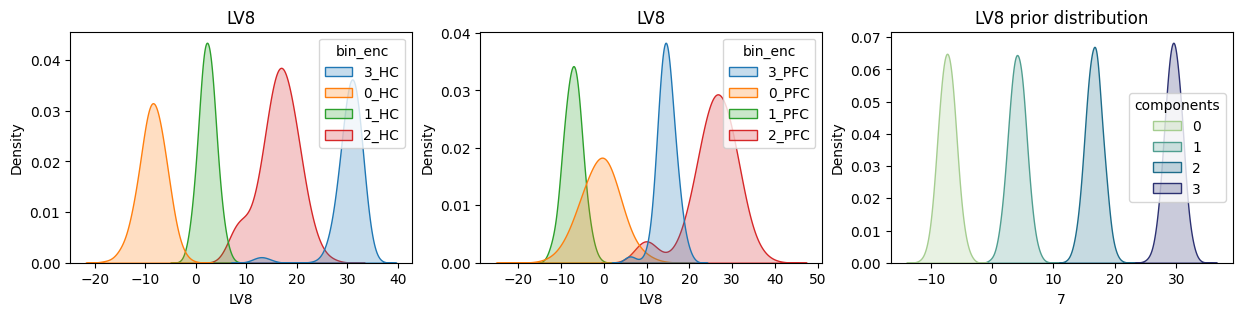

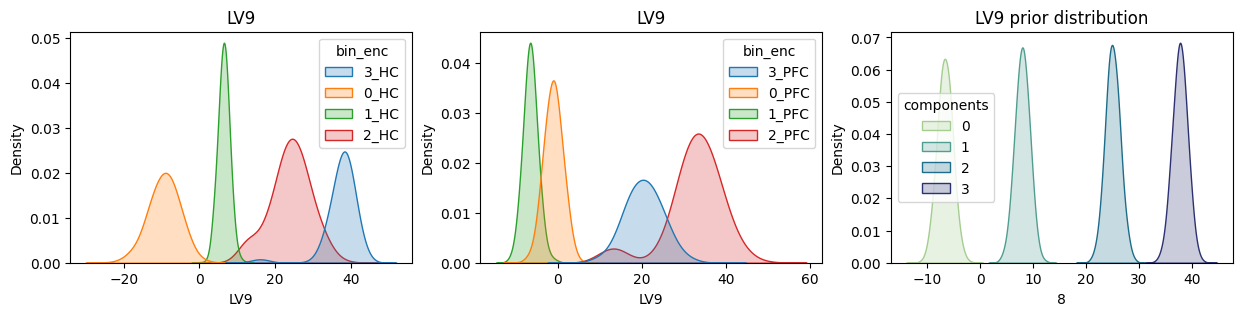

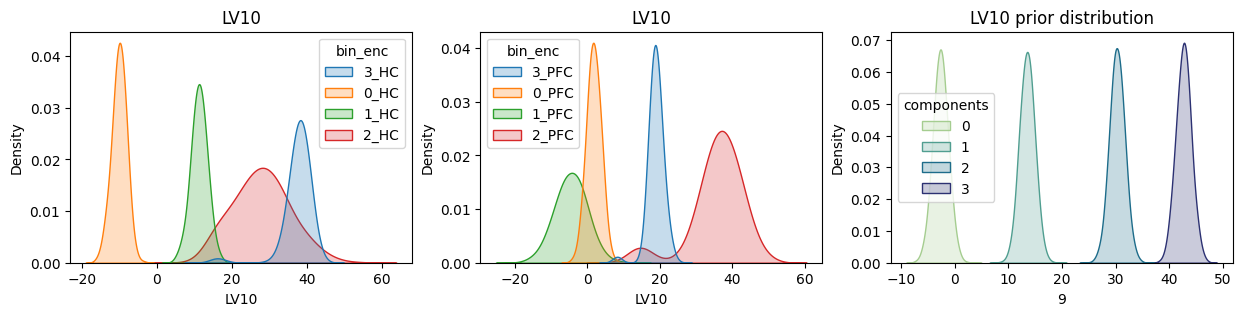

In [60]:
for i, column in enumerate(latent_space_comb.columns[:latent_dim]):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    hc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[0])]
    sns.kdeplot(data=hc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[0])
    ax[0].set_title(column)
    pfc = latent_space_comb[latent_space_comb['bin_enc'].str.contains(dataset_abbrev[1])]
    sns.kdeplot(data=pfc[[column, 'bin_enc']], x=column, hue='bin_enc', fill=True, bw_adjust=2, ax=ax[1])
    ax[1].set_title(column)
    prior_col = prior_samples.columns[i]
    sns.kdeplot(data=prior_samples[[prior_col, 'components']], x=prior_col, hue='components', palette = 'crest',fill=True, bw_adjust=2, ax=ax[2])
    ax[2].set_title(f'{column} prior distribution')

Plot the centers over epochs

In [61]:
from scipy.stats import norm

In [72]:
gmm_centers[0].shape

torch.Size([4, 10])

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_latent_progression(epoch_data_list, osd_epochs, latent_dim, std=0.2, every_n_epochs=500):
    epochs_to_plot = range(0, len(epoch_data_list), every_n_epochs)
    num_plots = len(epochs_to_plot)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(10, num_plots * 1.0), sharex=True)
    if num_plots == 1: axes = [axes] 
    
    all_means = np.array(epoch_data_list)[:, :, latent_dim]
    xmin, xmax = np.min(all_means) - 3*std, np.max(all_means) + 3*std
    x = np.linspace(xmin, xmax, 500)

    colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

    for i, epoch_idx in enumerate(epochs_to_plot):
        means = np.array(epoch_data_list[epoch_idx]) 
        ax = axes[i]

        osd = osd_epochs[epoch_idx]
        
        #ax.set_ylim(0, 2.5)

        for bin_idx in range(4):
            m = means[0, bin_idx, latent_dim]
            y = norm.pdf(x, m, std)
            
            ax.plot(x, y, color=colors[bin_idx], lw=1.5, alpha=0.8, label=f'Bin {bin_idx}')
            ax.fill_between(x, y, color=colors[bin_idx], alpha=0.3)
    
        ax.set_ylabel(f"Epoch {epoch_idx}\nOSD: {osd:.4f}", 
                      fontweight='bold', rotation=0, labelpad=40, va='center')

        #ax.set_ylabel(f'Ep {epoch_idx}', rotation=0, labelpad=30, va='center')
        ax.set_yticks([])
        ax.patch.set_alpha(0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)

        if i==0: 
            ax.legend(loc='upper right')
        
    plt.xlabel(f"Latent Dimension {latent_dim} Value")
    plt.xlim(xmin, xmax)
    plt.subplots_adjust(hspace=0.5) # This "stacks" them closely
    plt.suptitle(f"Progression of Bin Separation (Dim {latent_dim})", y=0.95)
    plt.show()
    plt.savefig(os.path.join(output_folder, 'bins_over_epochs.png'))

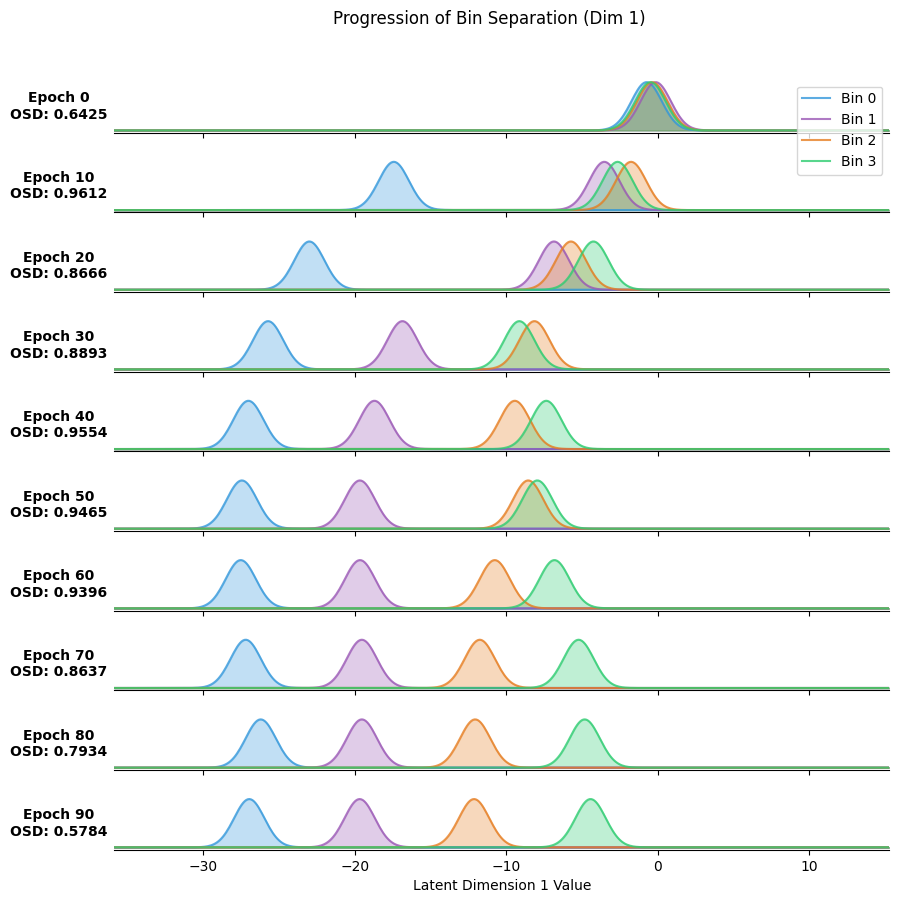

<Figure size 640x480 with 0 Axes>

In [63]:
plot_latent_progression(bin_means_epochs, osd_epochs, latent_dim=1, std=1, every_n_epochs=10)

In [83]:
len(bin_means_epochs[0][0])

4

In [106]:
def plot_latent_progression(epoch_data_list, osd_epochs, gmm_centers, latent_dim, std=0.2, every_n_epochs=500, output_folder='.'):
    # epoch_data_list structure: [num_epochs][num_encoders][num_bins (of latent_dim size)]
    # gmm_centers structure: [num_epochs][num_encoders][num_bins][latent_dim]
    
    epochs_to_plot = range(0, len(epoch_data_list), every_n_epochs)
    num_plots = len(epochs_to_plot)
    
    fig, axes = plt.subplots(num_plots, 2, figsize=(14, num_plots * 1.5), sharex=True)
    if num_plots == 1: axes = np.expand_dims(axes, axis=0)
    
    # Calculate global limits based on the nested structure
    all_means = [bin_data[latent_dim] for epoch in epoch_data_list for encoder in epoch for bin_data in encoder]
    all_means = np.array(all_means)
    xmin, xmax = np.min(all_means) - 3*std, np.max(all_means) + 3*std
    x = np.linspace(xmin, xmax, 500)
    colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71']

    for i, epoch_idx in enumerate(epochs_to_plot):
        osd = osd_epochs[epoch_idx]
        
        # Accessing nested lists for current epoch
        current_epoch_data = epoch_data_list[epoch_idx] # list of 2 encoders
        current_epoch_centers = gmm_centers # list of 2 encoders
        
        for enc_idx in range(2):
            ax = axes[i, enc_idx]
            encoder_bins = current_epoch_data[enc_idx]
            encoder_centers = current_epoch_centers[enc_idx]
            
            for bin_idx in range(len(encoder_bins)):
                # Access latent_dim from the bin vector
                m = encoder_bins[bin_idx][latent_dim]
                y = norm.pdf(x, m, std)
                
                ax.plot(x, y, color=colors[bin_idx % len(colors)], lw=1.5, alpha=0.8, label=f'Bin {bin_idx}')
                ax.fill_between(x, y, color=colors[bin_idx % len(colors)], alpha=0.3)
                
                # Plot GMM center as a red dot
                center_val = encoder_centers[bin_idx][latent_dim]
                ax.scatter(center_val, 0, color='red', zorder=5, s=30, marker='o')

            if i == 0:
                ax.set_title(f"Encoder {dataset_abbrev[enc_idx]}")
                ax.legend()
            if enc_idx == 0:
                ax.set_ylabel(f"Epoch {epoch_idx}\nOSD: {osd:.4f}", 
                              fontweight='bold', rotation=0, labelpad=50, va='center')
            
            ax.set_yticks([])
            ax.spines[['top', 'right', 'left']].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.suptitle(f"Progression of Bin Separation (Dim {latent_dim})", y=0.98)
    
    save_path = os.path.join(output_folder, f'bins_dim_{latent_dim}_over_epochs.png')
    plt.savefig(save_path)
    plt.show()

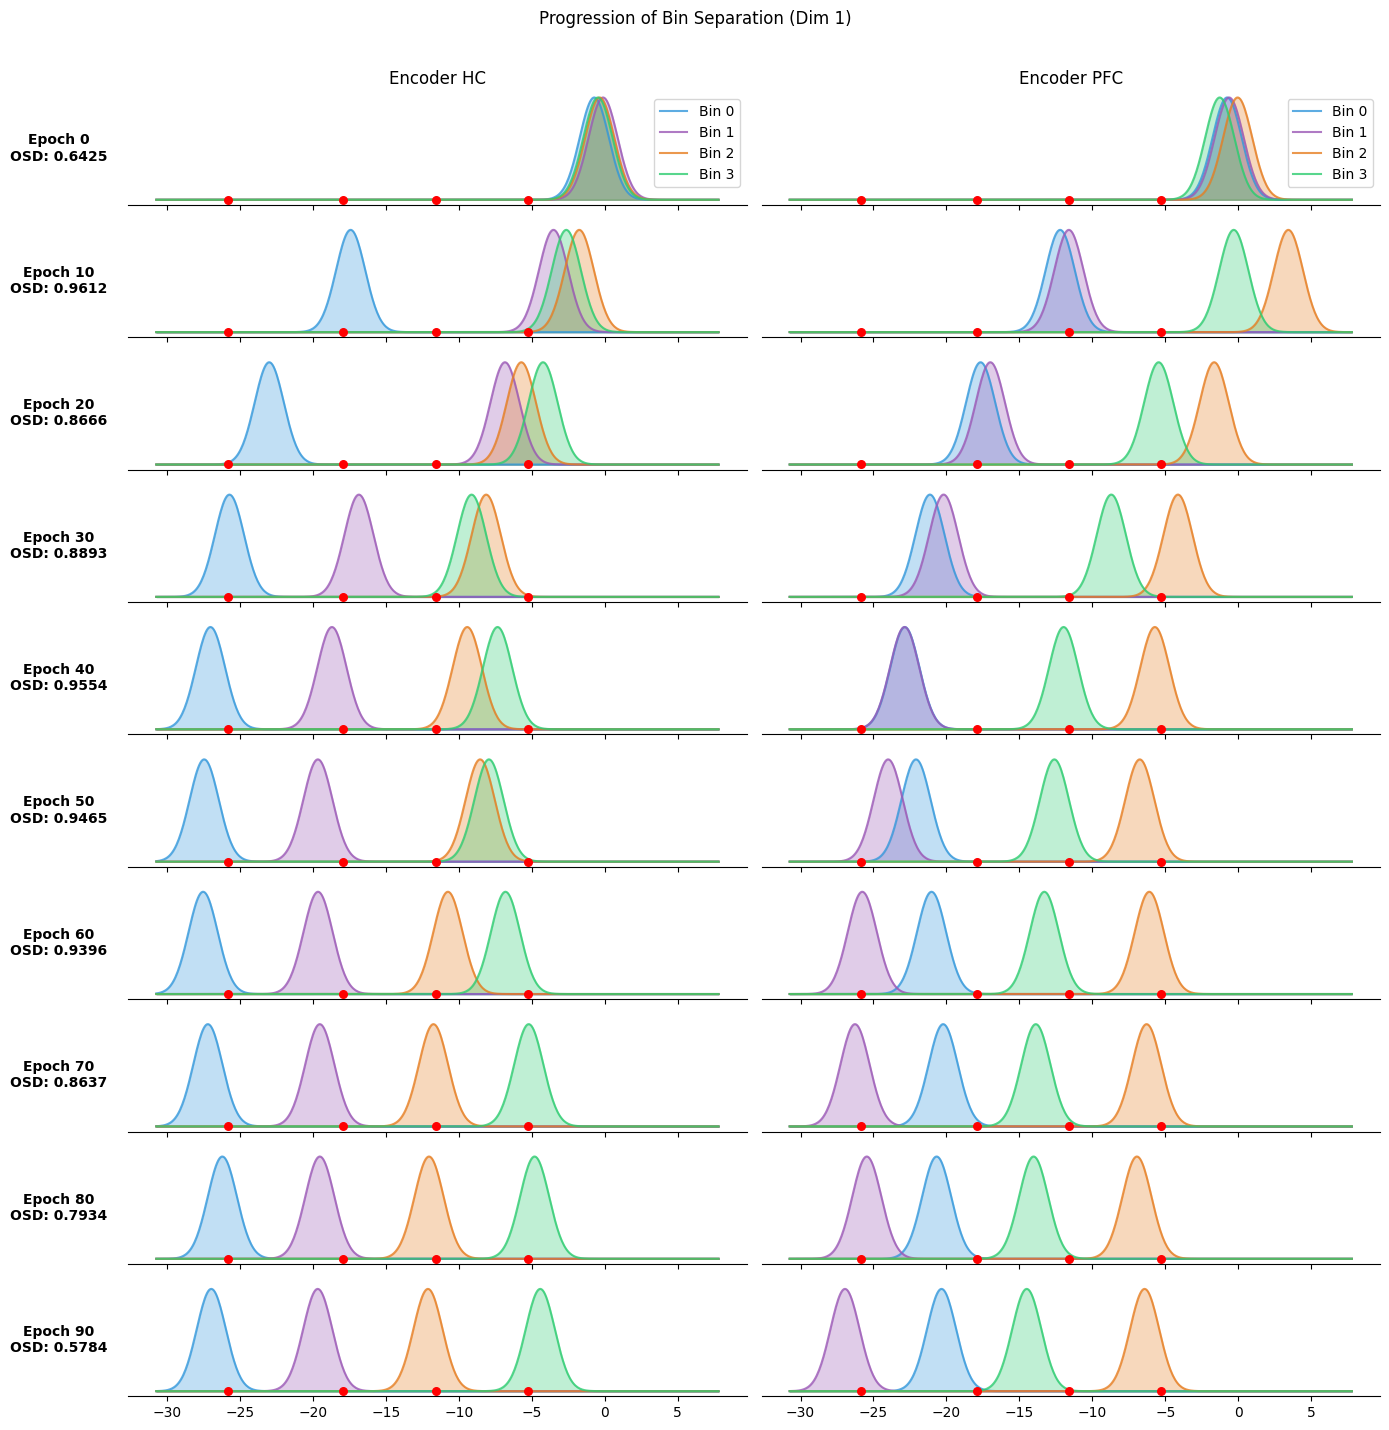

In [107]:
plot_latent_progression(bin_means_epochs, osd_epochs, gmm_centers, 1, 1, 10, output_folder)

In [64]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [65]:
hues = ['encoder', 'bin']

In [66]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

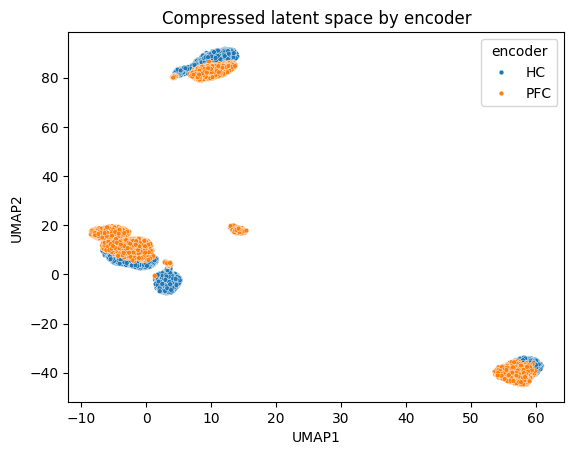

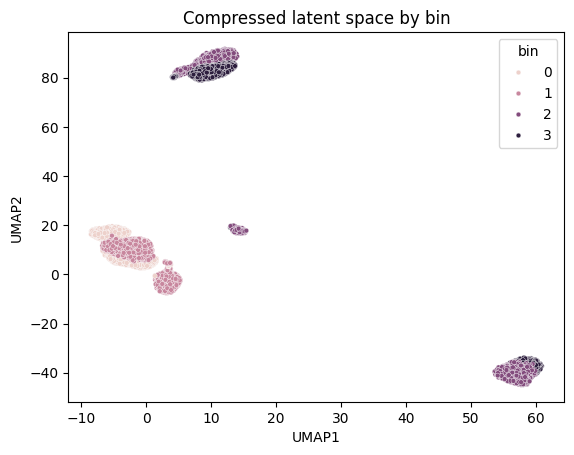

In [67]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [68]:
tsne = TSNE(n_components=2, perplexity=30, random_state=random_seed)
tsne_embeddings = tsne.fit_transform(latent_space_comb.iloc[:, :latent_dim])
tsne_embedding_df = pd.DataFrame(tsne_embeddings, columns=['t-SNE1', 't-SNE2'])
for hue in hues: 
    tsne_embedding_df[hue] = latent_space_comb[hue]

KeyboardInterrupt: 

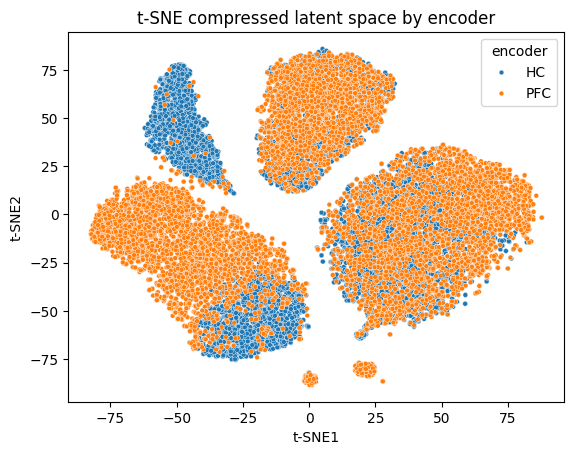

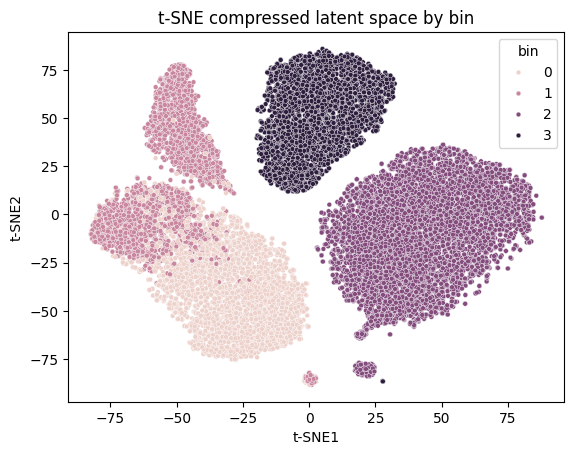

In [ ]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='t-SNE1', y='t-SNE2', hue=hue, data=tsne_embedding_df, s=12)
    plt.title(f't-SNE compressed latent space by {hue}')

Calculate and plot phenotypic projection

Latent space f-statistics

In [ ]:
# latent_space_PFC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaePFC.csv')
# latent_space_PFC

In [ ]:
# latent_space_HC = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_final/multiregion_seed22/latent_variables_epoch5000_vaeHC.csv')
# latent_space_HC

In [ ]:
# latent_space_comb = pd.concat([latent_space_PFC, latent_space_HC])
# latent_space_comb = latent_space_comb.reset_index()
# latent_space_comb = latent_space_comb.iloc[:, 1:]
# latent_dim=10
# dataset_abbrev = ['HC', 'PFC']

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif

le = LabelEncoder()
y = le.fit_transform(latent_space_comb['encoder'])
y

array([0, 0, 0, ..., 1, 1, 1])

In [ ]:
f_values, p_values = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(f_values)[::-1]
latents_ordered

array([9, 3, 6, 4, 1, 8, 5, 7, 2, 0])

In [ ]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with encoder classification')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {f_values[col], p_values[col]}')

Latent feature variance correlations with encoder classification
LV10: (134.46130012342104, 5.473461282373187e-31)
LV4: (13.564954269239124, 0.00023107056130401574)
LV7: (12.114299573267154, 0.0005014601313680488)
LV5: (9.723169575995982, 0.0018222422886075092)
LV2: (8.940249298375049, 0.002793027510781399)
LV9: (3.272180673037859, 0.07047929532911122)
LV6: (2.8206323594229525, 0.09307575411899849)
LV8: (2.4290550972612057, 0.11912090137836778)
LV3: (0.2711264213911559, 0.6025830704804307)
LV1: (0.2552356575235772, 0.6134180903672325)


In [ ]:
fclass_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'f_values': f_values,
    'p_values': p_values
}).sort_values(by='f_values', ascending=False)
fclass_importance_df

,Latent variable,f_values,p_values
9,LV10,134.461300,5.473461e-31
3,LV4,13.564954,2.310706e-04
6,LV7,12.114300,5.014601e-04
4,LV5,9.723170,1.822242e-03
1,LV2,8.940249,2.793028e-03
8,LV9,3.272181,7.047930e-02
5,LV6,2.820632,9.307575e-02
7,LV8,2.429055,1.191209e-01
2,LV3,0.271126,6.025831e-01
0,LV1,0.255236,6.134181e-01


SVM to predict features relevant to encoder classification

In [ ]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

In [ ]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
results = permutation_importance(rbf_model, latent_space_comb.iloc[:, :latent_dim], y, n_repeats=10, random_state=random_seed)

In [ ]:
rbf_importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': results.importances_mean, 
    'Abs_weight': abs(results.importances_mean)
}).sort_values(by='Abs_weight', ascending=False)
rbf_importance_df
rbf_importance_df.to_csv(os.path.join(output_folder, 'rbf_svm_weights.csv'))

In [ ]:
for i in results.importances_mean.argsort()[::-1]:
    print(f"{latent_cols[i]}: {results.importances_mean[i]:.4f}")

LV10: 0.2561
LV7: 0.1641
LV8: 0.1316
LV4: 0.1264
LV9: 0.1197
LV5: 0.0868
LV6: 0.0857
LV1: 0.0622
LV3: 0.0547
LV2: 0.0272


In [ ]:
# with linear kernel 
linear_model = SVC(kernel='linear')
linear_model.fit(latent_space_comb.iloc[:, :latent_dim], y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
weights = linear_model.coef_[0]
importance_df = pd.DataFrame({
    'Latent variable': latent_cols, 
    'Weight': weights, 
    'Abs_weight': abs(weights)
}).sort_values(by='Abs_weight', ascending=False)
importance_df.to_csv(os.path.join(output_folder, 'linear_svm_weights.csv'))

Generate correlation plots between latent variables

In [ ]:
from itertools import product

In [ ]:
latent_space_comb

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,bin,cfm,encoder,strain,14-6-residual,bin_enc
0,-18.166506,-12.708038,-8.739767,-5.656107,-1.414962,2.259596,9.562865,12.130691,17.635410,16.483486,3,1.243151,HC,124,1.277393,3_HC
1,-21.211752,-14.871796,-8.771109,-5.459798,2.377626,6.099314,9.455709,15.009495,24.047690,18.929396,3,1.243151,HC,124,1.277393,3_HC
2,-20.031376,-13.573089,-8.643621,-4.487203,6.550177,-0.439281,9.803576,13.413222,20.612396,18.981462,3,1.243151,HC,124,1.277393,3_HC
3,-14.624944,-9.267174,-10.218883,-7.431706,2.550920,2.235583,9.856035,10.063621,16.455854,15.344682,3,1.243151,HC,124,1.277393,3_HC
4,-20.253437,-13.009487,-12.165920,-6.355815,1.455625,6.213711,9.608272,14.483005,22.169186,17.858667,3,1.243151,HC,124,1.277393,3_HC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19497,-27.695976,-24.743868,-22.627096,-20.710682,-17.706512,-13.419691,-16.190914,-6.267247,0.854526,-2.280064,1,-0.215123,PFC,28,-0.576731,1_PFC
19498,-30.977259,-28.650320,-21.789309,-21.784994,-20.942010,-9.941216,-12.801998,-8.217599,-2.339671,0.963890,1,-0.215123,PFC,28,-0.576731,1_PFC
19499,-32.722580,-24.986744,-24.074556,-19.080225,-10.568300,-16.660553,-19.293606,-3.196782,0.595921,-2.319045,1,-0.215123,PFC,28,-0.576731,1_PFC
19500,-30.512657,-24.111595,-23.489504,-20.373873,-11.092814,-9.227627,-8.303705,-6.634022,-3.548368,-0.737546,1,-0.215123,PFC,28,-0.576731,1_PFC


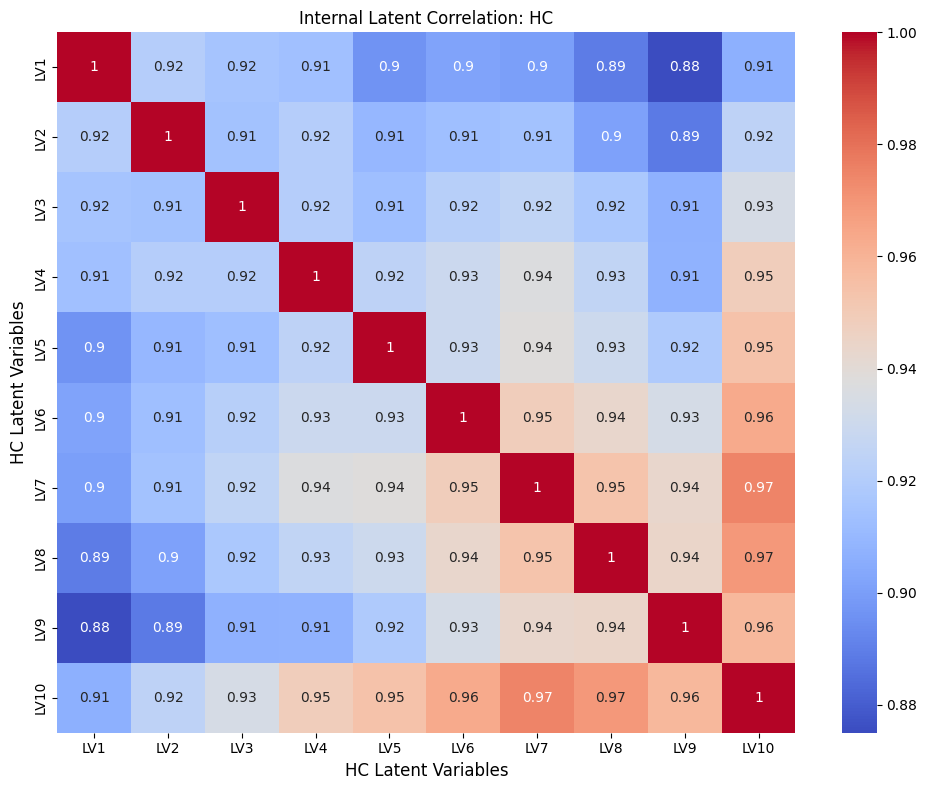

<Figure size 640x480 with 0 Axes>

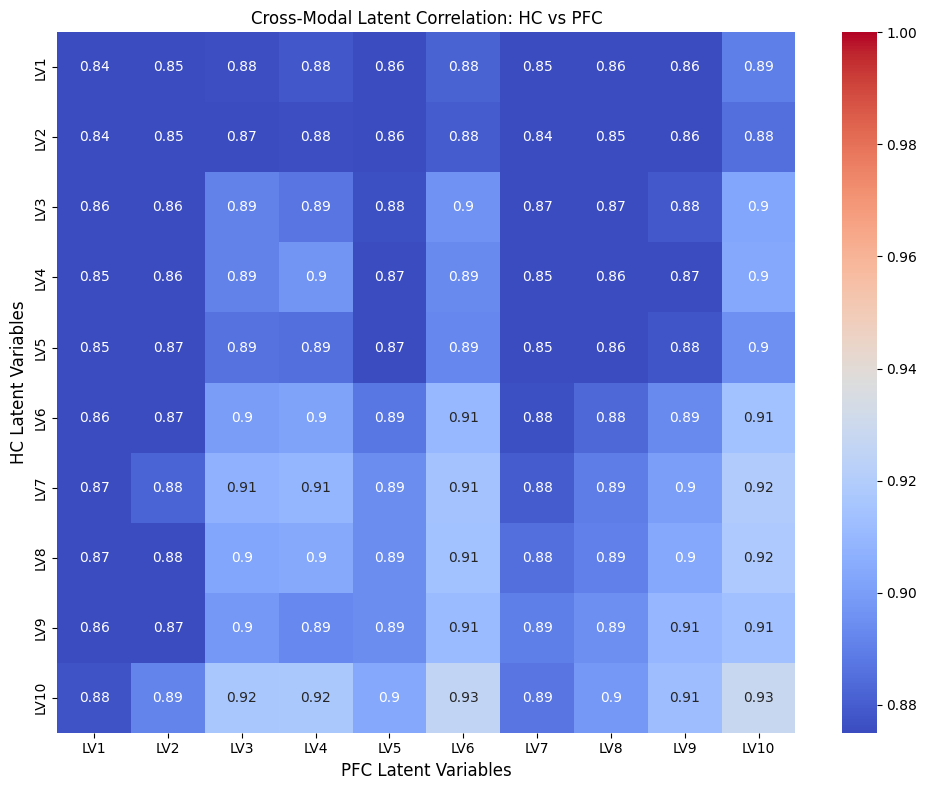

<Figure size 640x480 with 0 Axes>

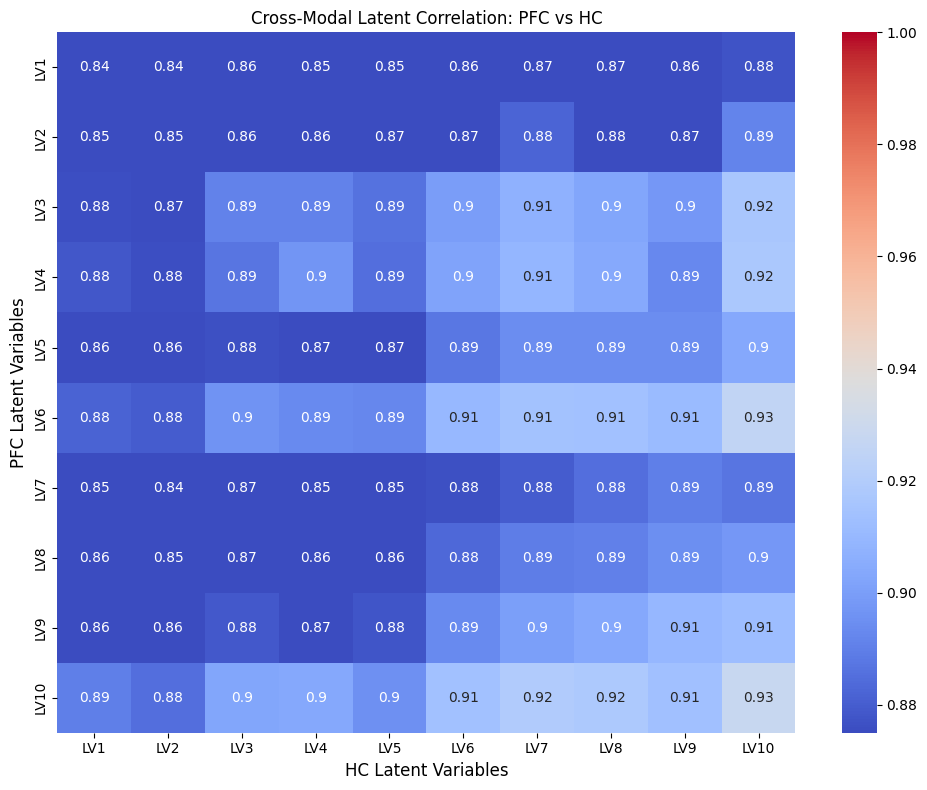

<Figure size 640x480 with 0 Axes>

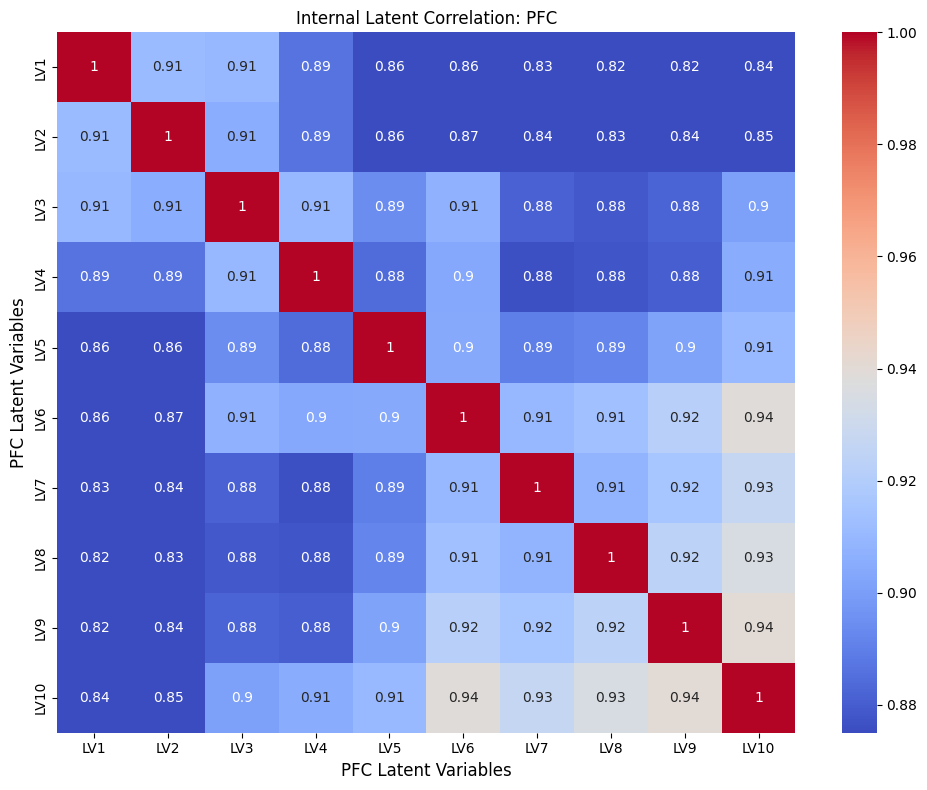

<Figure size 640x480 with 0 Axes>

In [ ]:
unique_encoders = latent_space_comb['encoder'].unique()
encoder_pairs = list(product(unique_encoders, repeat=2))
for enc1, enc2 in encoder_pairs:
    z1 = latent_space_comb[latent_space_comb['encoder'] == enc1].iloc[:, :latent_dim]
    z2 = latent_space_comb[latent_space_comb['encoder'] == enc2].iloc[:, :latent_dim]
    
    if len(z1) != len(z2):
        print(f"Skipping {enc1} vs {enc2} due to row count mismatch.")
        continue

    stacked = np.hstack((z1, z2))
    full_corr = np.corrcoef(stacked.T)
    cross_corr = full_corr[:latent_dim, latent_dim:]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cross_corr, 
        annot=True, 
        cmap='coolwarm', 
        xticklabels=latent_cols,
        yticklabels=latent_cols, 
        vmin=0.875, 
        vmax=1
    )
    
    plt.xlabel(f"{enc2} Latent Variables", fontsize=12)
    plt.ylabel(f"{enc1} Latent Variables", fontsize=12)
    if enc1 == enc2:
        plt.title(f"Internal Latent Correlation: {enc1}")
    else:
        plt.title(f"Cross-Modal Latent Correlation: {enc1} vs {enc2}")
    plt.tight_layout()
    plt.show()
    if enc1 == enc2:
        plt.savefig(os.path.join(output_folder, f"InternalLatentCorrelation:{enc1}.png"))
    else:
        plt.savefig(os.path.join(output_folder, f"Cross-ModalLatentCorrelation:{enc1}vs{enc2}.png"))